Loaded: dataset_5nodes\labels.csv
Shape: (28096, 7)
Columns: ['Path', 'Consolidation', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia', 'No Finding']

First rows:


,Path,Consolidation,Infiltration,Mass,Nodule,Pneumonia,No Finding
0,00000002_000.png,0,0,0,0,0,1
1,00000004_000.png,0,0,1,1,0,0
2,00000005_005.png,0,0,0,0,0,1
3,00000008_002.png,0,0,0,1,0,0
4,00000011_005.png,0,1,0,0,0,0



Label columns: ['Consolidation', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia', 'No Finding']

Distribution:


,count,percent
Pneumonia,6105,21.73
Infiltration,5740,20.43
Nodule,5634,20.05
Mass,5564,19.80
No Finding,5000,17.80
Consolidation,4481,15.95



Total images: 28096
Images with at least one label: 28096
Images with no findings: 5000
Average labels per image: 1.16


C:\Users\Edrill-LT\AppData\Local\Temp\ipykernel_22324\1240679076.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='label', y='count', data=dist_reset, palette="viridis")



Saved plot to dataset_5nodes\label_distribution.png


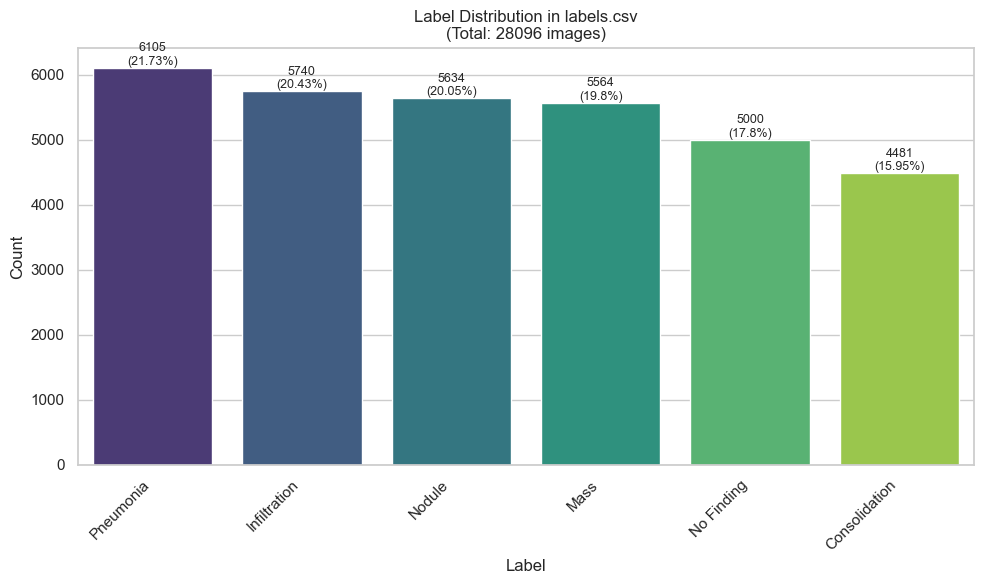

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

path = Path("./dataset_5nodes/labels.csv")
if not path.exists():
    print(f"File not found: {path}")
    raise SystemExit(1)

# Load CSV
df = pd.read_csv(path)
print("Loaded:", path)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nFirst rows:")
display(df.head())

# Get label columns (all columns except 'Path')
label_columns = [col for col in df.columns if col != 'Path']
print(f"\nLabel columns: {label_columns}")

# Count occurrences of each label (sum of 1s in each column)
counts = df[label_columns].sum().sort_values(ascending=False)
total_items = counts.sum()

# Create distribution dataframe
dist = pd.DataFrame({
    "count": counts,
    "percent": (counts / len(df) * 100).round(2)  # Percentage of total images
})
print("\nDistribution:")
display(dist)

# Additional statistics
print(f"\nTotal images: {len(df)}")
print(f"Images with at least one label: {(df[label_columns].sum(axis=1) > 0).sum()}")
print(f"Images with no findings: {df['No Finding'].sum()}")
print(f"Average labels per image: {df[label_columns].sum(axis=1).mean():.2f}")

# Plot distribution
plt.figure(figsize=(10, 6))
dist_reset = dist.reset_index()
dist_reset.columns = ['label', 'count', 'percent']
ax = sns.barplot(x='label', y='count', data=dist_reset, palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.xlabel("Label")
plt.title(f"Label Distribution in {path.name}\n(Total: {len(df)} images)")
plt.tight_layout()

# Annotate bars with counts and percent
for i, (idx, row) in enumerate(dist.iterrows()):
    ax.text(i, row['count'], 
            f"{int(row['count'])}\n({row['percent']}%)", 
            ha="center", va="bottom", fontsize=9)

out_png = path.parent / "label_distribution.png"
plt.savefig(out_png, dpi=150, bbox_inches='tight')
print(f"\nSaved plot to {out_png}")
plt.show()